# Tree topologies with PyTTN

In this tutorial we will provide a basic overview of the tools within pyTTN for the definition of tree topologies for use as tensor network ansatz.  

### Contents

1. [Matrix Product States](#matrix-product-states)

2. [Visualising Trees](#visualising-tensor-networks)

3. [Sanitising Tree Diagrams](#sanitise-tree-diagrams)

4. [ML-MCTDH Ansatz](#ml-mctdh-ansatz)

5. [Custom Tree Building](#custom-tree-building)

    - [Getting Started](#getting-started)

    - [Adding Nodes Manually](#adding-nodes-manually)

    - [Adding MPS Subtrees](#adding-mps-subtrees)

    - [Adding ML-MCTDH Subtrees](#adding-ml-mctdh-subtrees)

    - [Adding to Leaf Nodes](#adding-to-leaf-nodes)

        - [Fork Matrix Product States](#fork-matrix-product-states)
    
6. [Automated Tree Generation](#automated-tree-generation)

    - [Spanning Trees](#spanning-trees)

    - [Hierarchical Clustering](#hierarchical-clustering)

7. [Updating Tree Properties](#updating-tree-properties)

8. [Traversing Trees](#traversing-trees)


Import libraries

In [2]:
import matplotlib.pyplot as plt 
import numpy as np 

%matplotlib inline

/home/lachlan/pyttn/.venv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


Import PyTTN dependencies

In [3]:
import pyttn

### Matrix Product States <a class="anchor" id="matrix-product-states"></a>

Matrix product states (MPS) are quantum states of many particles written in the form 

$|\Psi\rangle = \sum_{\sigma_1,...,\sigma_L} A^{\sigma_1}A^{\sigma_2}...A^{\sigma_L-1}A^{\sigma_L} |\sigma_1,...,\sigma_L\rangle$

In [4]:
# Number of sites in MPS
N = 10

# Maximum bond dimension
chi = 8

# Vector of dimensions of the local Hilbert space in the physical nodes
dims = [2 for i in range(N)]

Tree tensor networks are created using the `ntreeBuilder`. Its function `mps_tree` creates an MPS with maximum virtual-bond dimension `chi`, and with the physical dimensions specified in `dims`.

In [5]:
topo = pyttn.ntreeBuilder.mps_tree(dims,chi)

### Visualising Tensor Networks <a class="anchor" id="visualising-tensor-networks"></a>

The function `visualise_tree` plots the tree diagram of the tensor network. It works along with `matplotlib`.

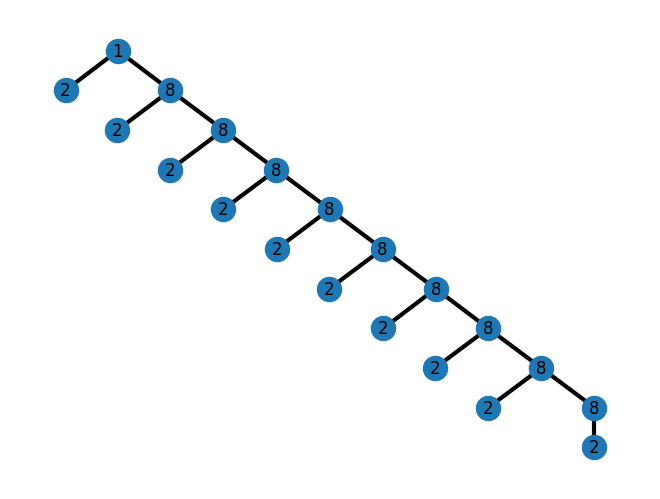

In [6]:
# Creating a figure is not needed here, but it is important 
# to remember it inside .py scripts
plt.figure()

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

The MPS is represented as a tree diagram in which the leaves (the nodes without children) represent the physical nodes, while the parent nodes form the "skeleton" of the MPS.

The numbers in each node represent the dimension of the bond above it (note that since tree tensor networks are loop free, every node will have just one parent node). For leaf nodes, this number indicates the dimension of the physical index of the MPS, and therefore the dimension of the Hilbert space of the degree of freedom they encode. In the code above, the physical dimensions are given by the vector `dim`. For the "skeleton" nodes, that number specifies the dimension of the virtual bonds connecting the site tensors of the MPS. The bond dimension is initialised to its maximum value `chi`. The node at the top of the tree is the root and has dimension 1—a scalar.

### Sanitise tree diagrams <a class="anchor" id="sanitise-tree-diagrams"></a>

The tensor network diagram can be optimised in a few ways to make calculations more efficient.

When working with large physical Hilbert spaces (i.e. large dimensions in the leaf nodes), it can be useful to work in a reduced-dimensional basis. To implement this transformation, the code inserts an extra node between the bond nodes (the ones that give shape to the MPS) and the physical nodes (the leaves). These basis nodes define a time-dependent local basis of a reduced dimension for the physical nodes. They are implemented as an attribute of `ntreeBuilder`.

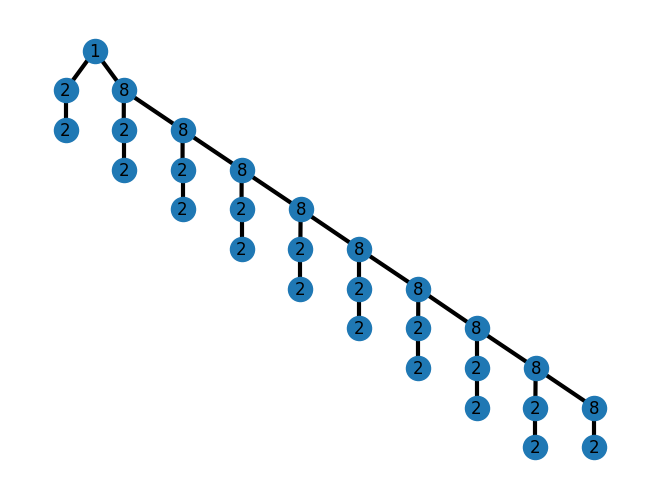

In [7]:
pyttn.ntreeBuilder.insert_basis_nodes(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

Another useful optimisation is to contract *bond* matrices that are connected to only two tensors. This is important for algorithms with adaptive bond dimension, since allowing for bond matrices as site tensors would stop the adaptation of the bond dimension from working.

The function `collapse_bond_matrices` contracts any bond matrix and tensors that are not physical or local-transformation nodes. 

In the tensor network above, this happens to the root node, which is contracted with the node to its right. That node becomes the new root of the tree, and again will have dimension 1.

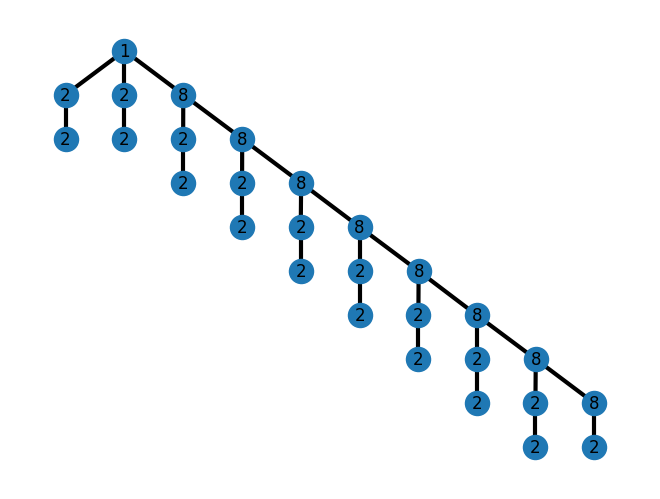

In [8]:
pyttn.ntreeBuilder.collapse_bond_matrices(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

One last useful optimisation is to make sure that bond dimensions being used are not larger than using a full basis for the degrees of freedom. This reduces the bond dimension in some bonds from its maximum value (to which it was initialised) to the effective bond dimension they encode.

In the example below, this reduces the dimension of the last two bonds of the MPS from 8 to 4 and 2.

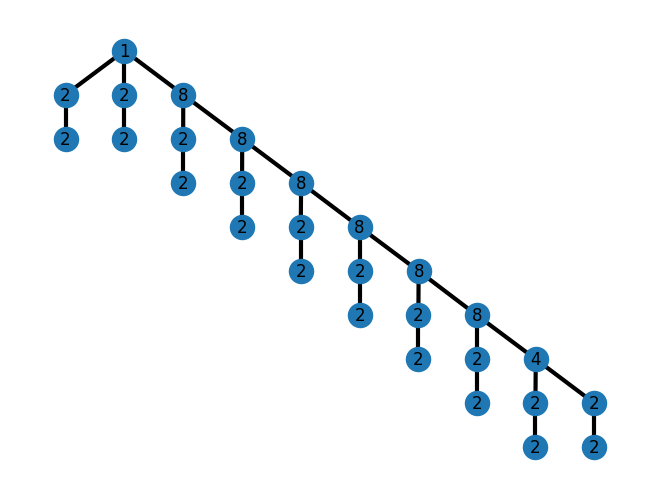

In [9]:
pyttn.ntreeBuilder.sanitise_bond_dimensions(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

All this processing of the tree diagram can be done at the same time with the function `sanitise` of `ntreeBuilder`—this is how it will be done for the rest of this tutorial.

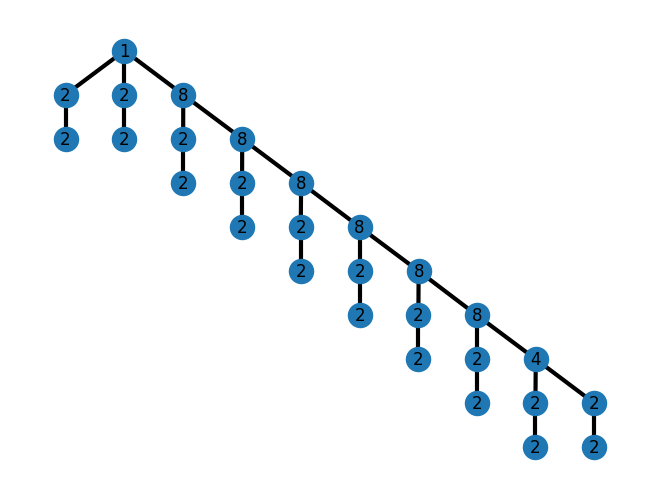

In [10]:
pyttn.ntreeBuilder.sanitise(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

### ML-MCTDH ansatz <a class="anchor" id="ml-mctdh-ansatz"></a>

Beyond Matrix Product States, the ML-MCTDH ansatz (short for Multi-Layer Multi-Configuration Time-Dependent Hartree ansatz) is a powerful method to simulate quantum many-body systems. The wavefunction is represented in a tree structure with several layers for the different levels of complexity.

The ML-MCTDH tree is constructed using the `mlmctdh_tree` function of `ntreeBuilder`. As with MPS, `chi` sets the maximum bond dimension, and `dims` specifies the dimensions of the physical bonds.

The parameter `degree` set the maximum number of children that a node can have. Depending on it, the tree will be binary, ternary, etc. The degree of the tree controls its depth by determining the number of layers needed to construct the number of physical degrees of freedom set by `dims`.

The nodes are ordered according to a *pre-order depth-first traversal* labelling of the nodes. In practice, this means that the left-most node is the first physical degree of freedom, and increasing towards the right.

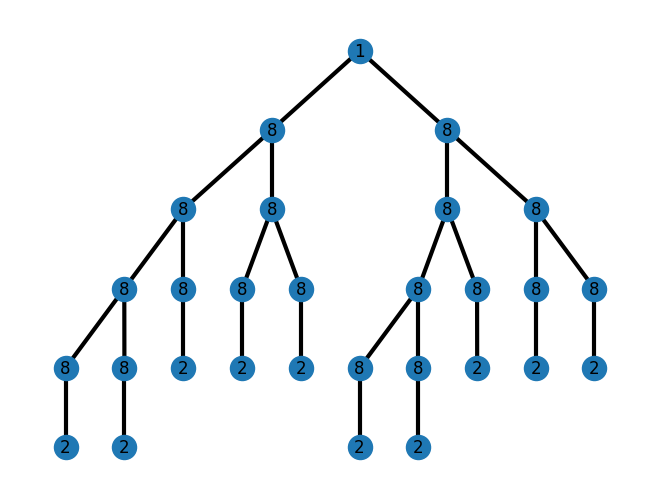

In [11]:
# Always larger than 1. Max number of child nodes for each node
degree = 2

topo = pyttn.ntreeBuilder.mlmctdh_tree(dims, degree, chi)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

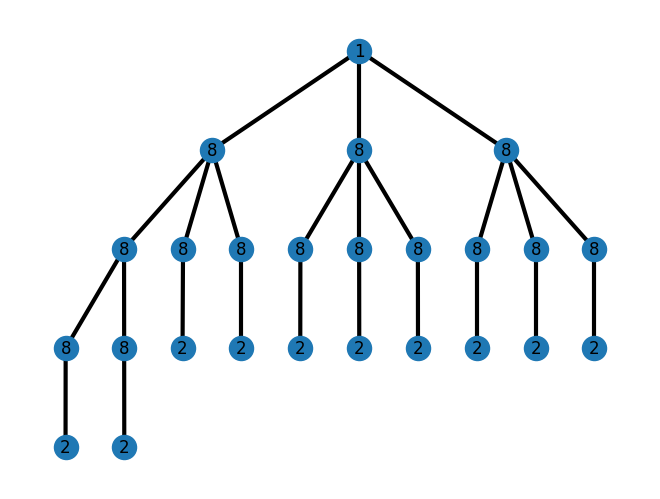

In [12]:
# Always larger than 1. Max number of child nodes for each node
degree = 3

topo = pyttn.ntreeBuilder.mlmctdh_tree(dims, degree, chi)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

### Custom tree building <a class="anchor" id="custom-tree-building"></a>

##### Getting Started <a id="getting-started"></a>

One may wish to create a tree with a topology different to an MPS or the ML-MCTDH ansatz. The function `ntree` can be used for that purpose, by writing the desired tree topology in parentheses notation.

In this notation, each pair of parentheses encloses a subtree, where the root node is followed by its child nodes inside parentheses. For example, the notation `(1(2)(3))` describes a tree with root node `1`, and two child nodes, `2` and `3`. Nested parentheses represent deeper levels of the tree: in the tree `(1(2(4)(5))(3))`, the node 2 has two child nodes itself, `4` and `5`.

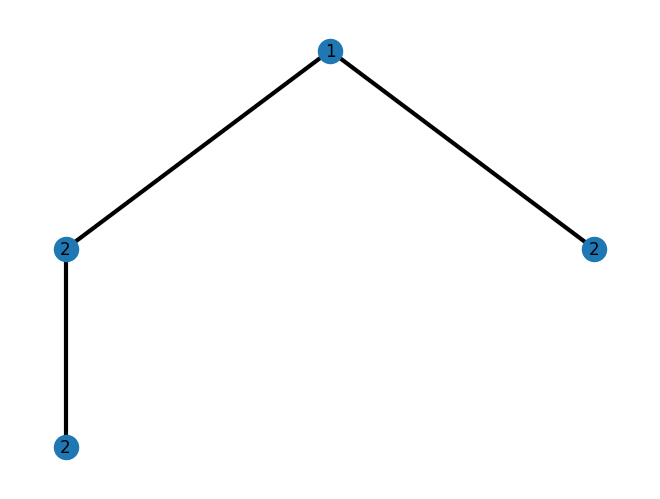

In [13]:
topo = pyttn.ntree("(1(2(2))(2))")

pyttn.utils.visualise_tree(topo)
plt.show()

To store and visualise the tree topology, the diagram can be printed in parentheses notation.

In [14]:
print(topo)

ntree : (1(2(2))(2));



##### Adding Nodes Manually <a id="adding-nodes-manually"></a>

Given an existing `ntree` object we can manually insert nodes within the tree in several different ways.  

First, we may select a node and add a new child node at the end of its child list using the `insert` function.  As an example we can add a node below the root of `topo` as follows:

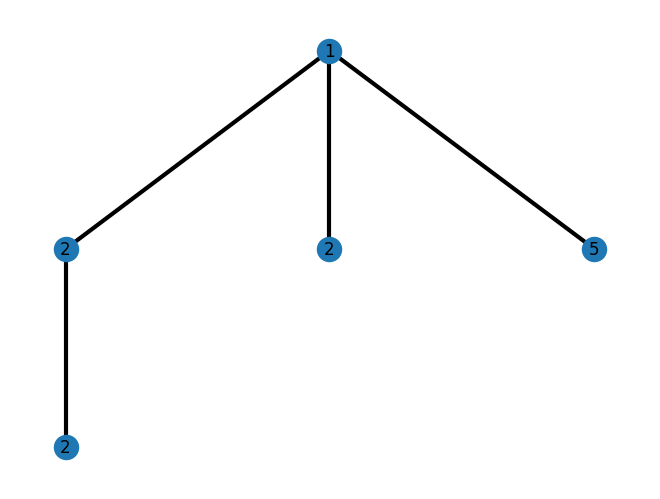

In [15]:
topology = pyttn.ntree(topo)

topology().insert(5)
pyttn.utils.visualise_tree(topology)
plt.show()

We may select a node and add a new child node at the start of its child list using the `insert_front` function.  As an example we can add a node below the root of `topo` as follows:

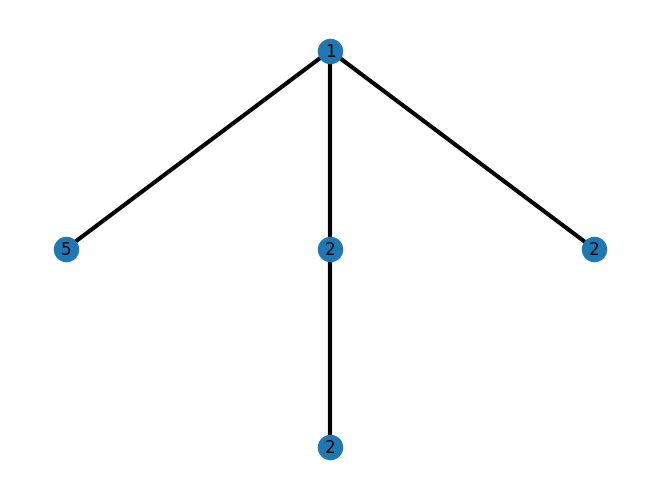

In [16]:
topology = pyttn.ntree(topo)

topology().insert_front(5)
pyttn.utils.visualise_tree(topology)
plt.show()

Or we can insert a new node as a child of a given node using the `ntree`.`insert_at` function that takes a target node position and the value to insert as its child.  

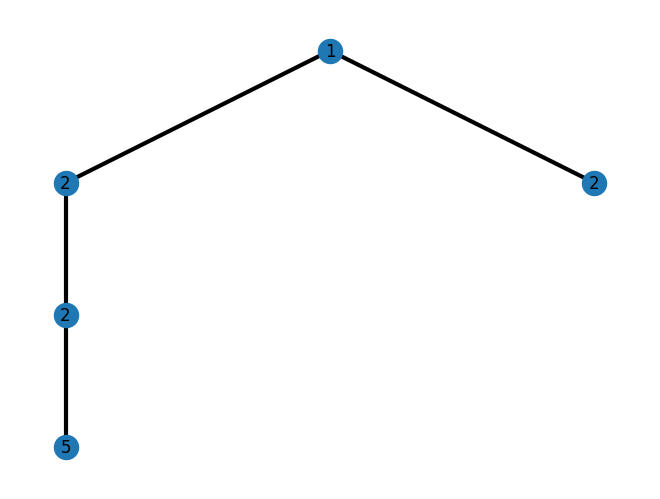

In [17]:
topology = pyttn.ntree(topo)

topology.insert_at([0,0], 5)
pyttn.utils.visualise_tree(topology)
plt.show()

##### Adding MPS subtrees <a id="adding-mps-subtrees"></a>

A useful functinonality of `ntreeBuilder` is to append MPS chains to custom trees. This is done with the function `mps_subtree`. It defines an MPS with maximum bond dimension `chi` and physical Hilbert-space dimensions `dims`. 

The MPS is attached to the node specified in the first argument of the function—in the example below, `topo()[1]`. In general, `topo()` specifies the root node of the tree. Nodes are ordered from left to right, so `topo()[0]` specifies the left child of the root node and `topo()[1]` specifies the right child node. The child of the left node could be selected as `topo()[0][0]`, and so on.

The last parameter of `mps_subtree`, if included, sets the dimension of the basis nodes, that implement a local Hilbert-space transformation between the physical nodes and the "skeleton" of the MPS. When omitted, the `sanitise` function will insert them automatically.

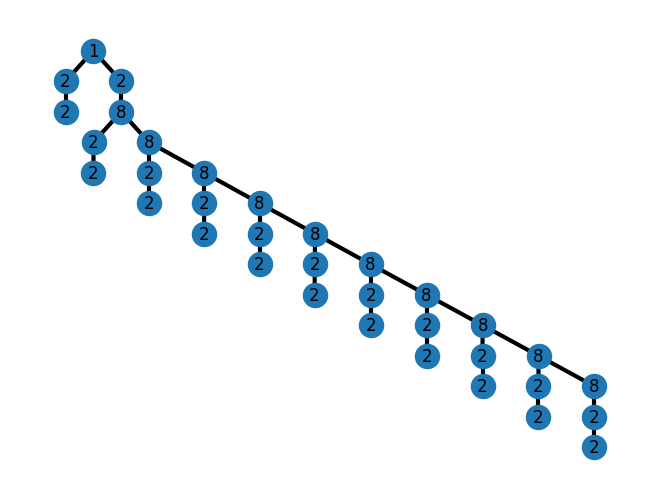

In [18]:
pyttn.ntreeBuilder.mps_subtree(topo()[1], dims, chi, 2)

# Plot tree diagrams
pyttn.utils.visualise_tree(topo)
plt.show()

Again, sanitising the tree is an important step to optimise the tree for internal processing. The `sanitise` function runs the three sanitation steps simultaneously.

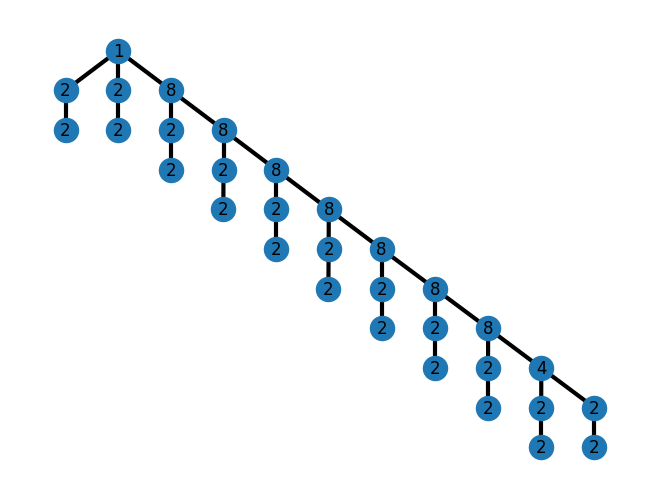

In [19]:
pyttn.ntreeBuilder.sanitise(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

##### Adding ML-MCTDH subtrees <a id="adding-ml-mctdh-subtrees"></a>

Instead of appending an MPS to the tree, one can instead append an ML-MCTDH tree. This is done with the function `mlmctdh_subtree`. It defines an ML-MCTDH tree of a specific `degree` with maximum bond dimension `chi` and physical Hilbert-space dimensions `dims`. 

As with the MPS subtree, the ML-MCTDH subtree is attached to the node addressed in the first argument of the function. In the example below, it will be attached to the second child (`[1]`) of the root node (`topo()`), that is, `topo()[1]`.

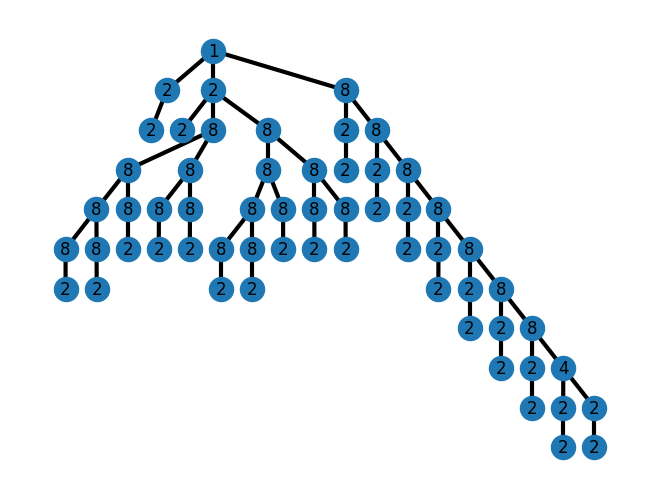

In [20]:
degree = 2

pyttn.ntreeBuilder.mlmctdh_subtree(topo()[1], dims, degree, chi)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

Again, sanitising the tree is an important step to optimise the tree for internal processing. The `sanitise` function runs the three sanitation steps simultaneously.

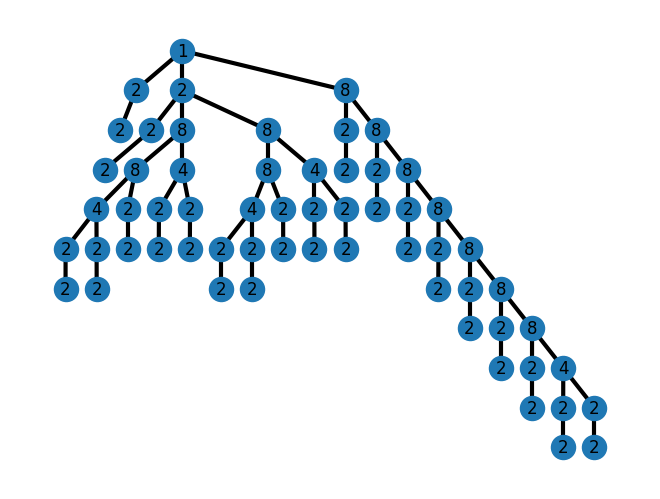

In [21]:
pyttn.ntreeBuilder.sanitise(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

##### Adding to Leaf Nodes <a id="adding-to-leaf-nodes"></a>

So far we have looked at cases where we are manually adding nodes or subtrees to a specific node in the tree.  Occasionally, we may want to construct more complex trees in which we first build a backbone tree, following which we append a set of subtrees to each leaf node of the backbone.  This can be performed easily with the use of the `leaf_indices` function, that returns a list of all leaves of the current tree.

As an example, we will consider the following degree 2 ML-MCTDH tree

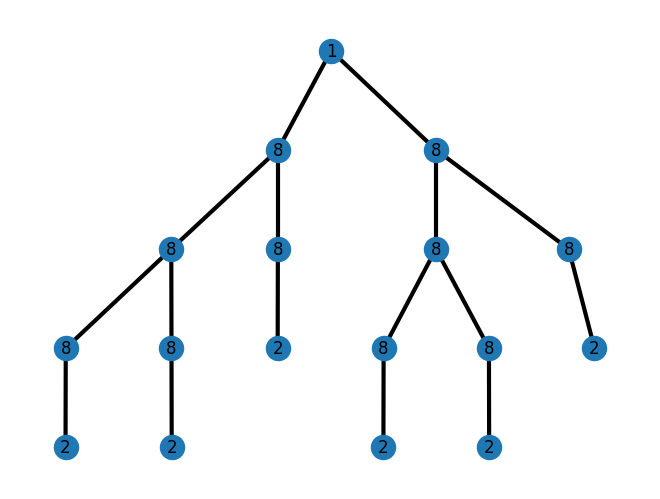

In [22]:
# Number of sites in the TTN
N = 6

# Maximum bond dimension
chi = 8

# Vector of dimensions of the local Hilbert space in the physical nodes
dims = [2 for i in range(N)]

# Always larger than 1. Max number of child nodes for each node
degree = 2

topo = pyttn.ntreeBuilder.mlmctdh_tree(dims, degree, chi)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

We can find the index of each node of this tree using the `leaf_indices` function:

In [23]:
print(topo.leaf_indices())

[[0, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0], [1, 0, 0, 0], [1, 0, 1, 0], [1, 1, 0]]


With access to these indices, we can now readily append nodes to the leaves of the tree.  As an example, we can attach MPS subtrees as follows:

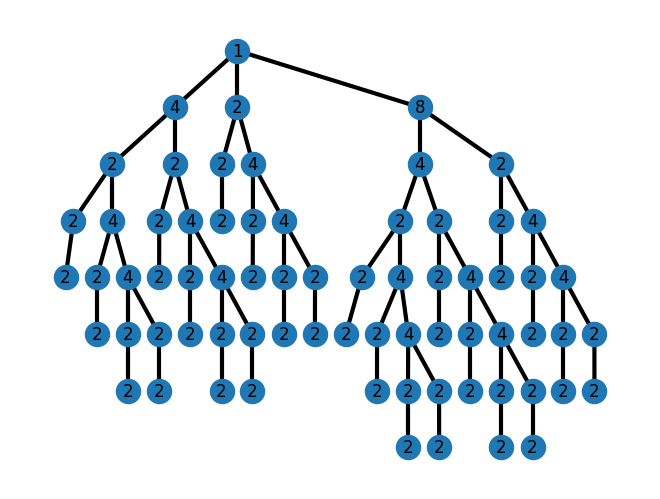

In [24]:
#build the ML-MCTDH tree
topo = pyttn.ntreeBuilder.mlmctdh_tree(dims, degree, chi)

#bond dimension for the MPS subtrees
chi_mps = 4

#local Hilbert space dimensions for the MPS subtrees
dims_mps = [2 for i in range(4)]

#iterate over each leaf index of the tree and append the MPS subtree
for lind in topo.leaf_indices():
    pyttn.ntreeBuilder.mps_subtree(topo.at(lind), dims_mps, chi_mps)

#sanitise the tree cleaning up any bond matrices
pyttn.ntreeBuilder.sanitise(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

##### Fork Matrix Product States <a id="fork-matrix-product-states"></a>

Using the above strategy it is straightforward to generate `ntree` objects for commonly used tensor network topologies, such as Fork Matrix Product States.  Here we show an example building a Fork MPS constructed of 6 different MPSs each of length 4.

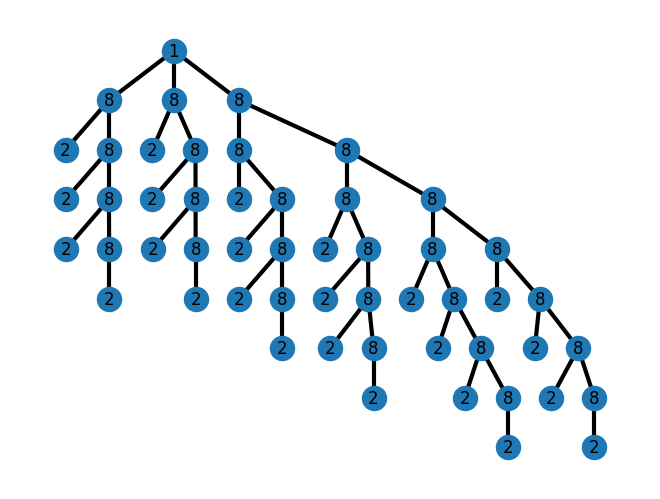

In [25]:
#bond dimension for the MPS subtrees
chi_fork = 8

#local Hilbert space dimensions for the MPS subtrees
dims_mps = [8 for i in range(6)]

#build the ML-MCTDH tree
topo = pyttn.ntreeBuilder.mps_tree(dims_mps, chi)

#bond dimension for the MPS subtrees
chi_mps = 8

#local Hilbert space dimensions for the MPS subtrees
dims_mps = [2 for i in range(4)]

#iterate over each leaf index of the tree and append the MPS subtree
for lind in topo.leaf_indices():
    pyttn.ntreeBuilder.mps_subtree(topo.at(lind), dims_mps, chi_mps)

#sanitise the tree cleaning up any bond matrices
pyttn.ntreeBuilder.collapse_bond_matrices(topo)

# Plot tree diagram
pyttn.utils.visualise_tree(topo)
plt.show()

### Automated Tree Generation <a class="anchor" id="automated-tree-generation"></a>

A key challenge in setting up calculations using tree tensor networks is the specification of an optimal tree structure for a given problem.  Ideally, one wants a tree structure in which strongly correlated degrees of freedom are connected by short paths throughout the tree.  This is generally a very challenging task, and often done by hand.  To avoid this difficulty, `pyTTN` provides functionality for generating plausible tree structures given a matrix providing some information about correlations between modes.  Some possible choices for the correlation matrix include:

* A matrix of the couplings between modes associated with a 2-local Hamiltonian
* A matrix of 2-body correlators associated with a ground state of the specified Hamiltonian
* A matrix containing the mutual information between different modes in the system

Here we will consider the first option, although for most purposes it is likely that the last two options will better capture correlations in the system of interest.  The inclusion of automated procedures for performing the latter two approaches is planned for future releases.

Given a matrix of correlations, `pyTTN` provides two strategies for generating tree structures based on the use of:

* Max Weight Spanning Trees 
* Hierarchical Clustering

The use of each of these approaches are demonstrated below:

#### Spanning Trees <a id="spanning-trees"></a>

We start by demonstrating the use of the spanning tree generation algorithm, applying it to several model problems.

##### Basic Functionality: A Coupled Spin-Boson Model

The first model we consider is a spin-chain model, with each spin being attached to its own star topology bath.  The coupling matrix for this system can be generated using the following function:

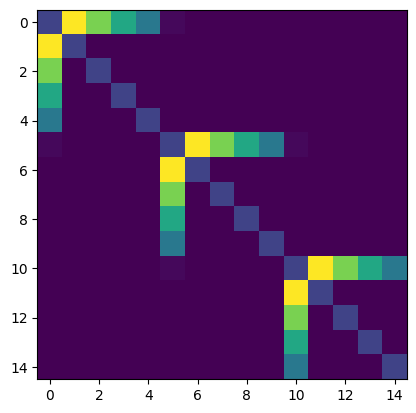

In [33]:
def msb_coupling_matrix(M : int, N : int) -> np.ndarray:
    """Generate the coupling matrix associated with a multi-spin boson model consisting of a chain of spins
    where each spin has its own bath and each bath.

    :param M: The number of spin degrees of freedom
    :type M: int
    :param N: The number of boson modes per spin
    :type N: int
    :return: The coupling matrix
    :rtype: np.ndarray
    """
    v = N+1-np.arange(N)  
    w = np.diag(np.ones(N))  

    gamma = np.zeros((N+1, N+1), dtype=float)
    gamma[0, 0] = 1
    gamma[0, 1:] = v
    gamma[1:, 0] = v
    gamma[1:, 1:] = w

    G2 = np.zeros((M*(N+1), M*(N+1)))
    for i in range(M):
        G2[i*(N+1):(i+1)*(N+1), i*(N+1):(i+1)*(N+1)] = gamma

    for i in range(M-1):
        G2[i*(N+1), (i+1)*(N+1)] = 0.1
        G2[(i+1)*(N+1), i*(N+1)] = 0.1
    return G2

correlation_matrix = msb_coupling_matrix(3, 4)
res = plt.imshow(correlation_matrix)

Now that we have the correlation matrix we can generate a tree structure, as a `networkx` tree, using the function `pyttn.generate_spanning_tree`

In [34]:
spanning_tree, spanning_root_ind = pyttn.generate_spanning_tree(correlation_matrix)

{0: 15, 1: 1, 2: 2, 3: 3, 4: 4, 5: 16, 6: 6, 7: 7, 8: 8, 9: 9, 10: 17, 11: 11, 12: 12, 13: 13, 14: 14}


From this we can generate the `ntree` object using the function `pyttn.convert_nx_to_tree`

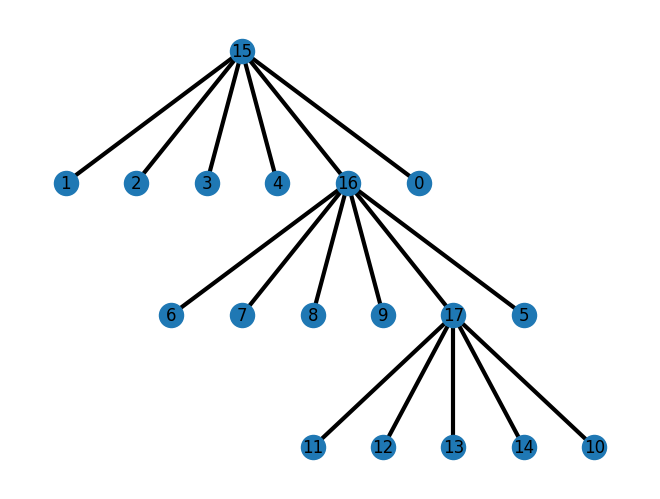

In [36]:
tree, leaf_ordering = pyttn.convert_nx_to_tree(spanning_tree, root_ind=spanning_root_ind)

pyttn.utils.visualise_tree(tree)

There are several things to note about this:

* The leaf nodes of the tree correspond to the index of the physical mode as defined by the correlation matrix.
* Interior nodes do not correspond to any physical degree of freedom and have a unique label.
* In addition to returning an `ntree` the function `pyttn.convert_nx_to_tree` returns a list of integers.  This list of integers defines the mode ordering to be used by the `system_modes` object for mapping tree nodes to physical degrees of freedom in the Hamiltonian.
* The resultant tree structure is the same as the tree structure shown in the original correlation matrix.  However, we note that this is quite a bad tree structure for use within a tensor network calculation as the nodes labelled 15, 16, and 17 are very high degree nodes, corresponding to high dimensional tensors (leading to large resource requirements at modest bond dimension).  

In order to generate sensible tree structures we need to constrain the maximum degree of the nodes in the tensor network, and this can be done within the `pyttn.generate_spanning_tree` function by constraining the maximum number of internal node children a node can have, and the maximum number of leaf node children a node can have, as follows:

[0, 0, 0, 0, 5]
(0, 1) [1, 2, 3, 4] [5]
[0, 0, 0, 0, 4]
(5, 6) [6, 7, 8, 9] [10]
[0, 0, 0, 0]
(10, 11) [11, 12, 13, 14] []
{0: 24, 1: 1, 2: 2, 3: 3, 4: 4, 5: 25, 6: 6, 7: 7, 8: 8, 9: 9, 10: 26, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23}


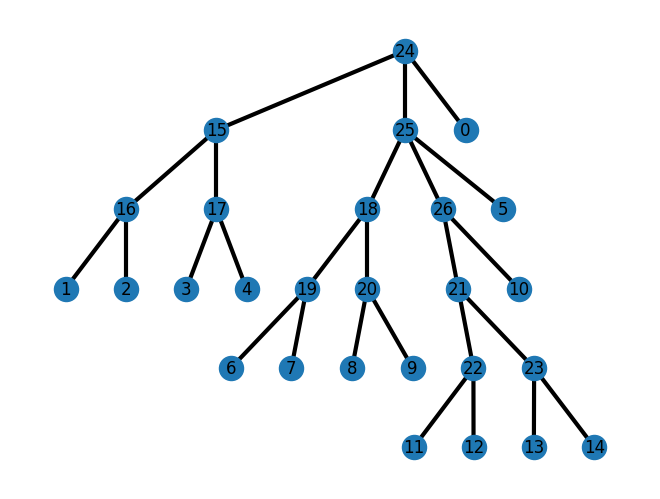

In [38]:
spanning_tree, spanning_root_ind = pyttn.generate_spanning_tree(correlation_matrix, max_internal_children=1, max_leaf_children=2)

tree, leaf_ordering = pyttn.convert_nx_to_tree(spanning_tree, root_ind=spanning_root_ind)

pyttn.utils.visualise_tree(tree)

Here we have now generated a tree structure corresponding to an MPS for the spin-variables (0, 5, 10) with each spin degree of freedom connected to a balanced binary tree containing the bosonic modes local to the spin.  In order to use this topology in a tensor network calculation we need to set the bond dimensions throughout the tree.  Details of how to do this are provided in the Section [Updating Tree Properties](#updating-tree-properties).

##### 24-mode Pyrazine

As a second example we consider the 24-mode Pyrazine model for which carefully hand-tuned tree structures have been developed over the years. 

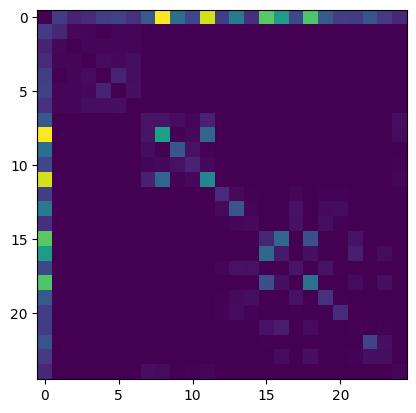

In [59]:
from pyrazine_parameters import *

def pyrazine_correlation_matrix():
    N = len(modes())

    G = np.ones((N, N))#*1e-5

    # the linear on-diagonal couplings
    #for i, g in enumerate(G1()):
        #G[0, mode_index(g)] += np.abs(ai()[i])+np.abs(bi()[i])
        #G[mode_index(g), 0] += np.abs(ai()[i])+np.abs(bi()[i])

    # the quadratic on-diagonal couplings
    for g, Aij, Bij in zip(G2(), aij(), bij()):
        for i, vi in enumerate(g):
            for j, vj in enumerate(g):
                G[mode_index(vi), mode_index(vj)] += np.abs(Aij[i, j])+np.abs(Bij[i, j])
                G[mode_index(vj), mode_index(vi)] += np.abs(Aij[i, j])+np.abs(Bij[i, j])
                G[0, mode_index(vj)] += np.abs(Aij[i, j])+np.abs(Bij[i, j])
                G[mode_index(vj), 0] += np.abs(Aij[i, j])+np.abs(Bij[i, j])
                G[0, mode_index(vi)] += np.abs(Aij[i, j])+np.abs(Bij[i, j])
                G[mode_index(vi), 0] += np.abs(Aij[i, j])+np.abs(Bij[i, j])


    # the linear off-diagonal couplings
    #for i, g in enumerate(G3()):
    #    G[0, mode_index(g)] += np.abs(ci()[i])
    #    G[mode_index(g), 0] += np.abs(ci()[i])

    # the quadratic on-diagonal couplings
    G4i, G4j = G4()
    for gi, gj, Cij in zip(G4i, G4j, cij()):
        for i, vi in enumerate(gi):
            for j, vj in enumerate(gj):
                G[mode_index(vi), mode_index(vj)] += np.abs(Cij[i, j])
                G[mode_index(vj), mode_index(vi)] += np.abs(Cij[i, j])
                G[0, mode_index(vj)] += np.abs(Cij[i, j])
                G[mode_index(vj), 0] += np.abs(Cij[i, j])
                G[0, mode_index(vi)] += np.abs(Cij[i, j])
                G[mode_index(vi), 0] += np.abs(Cij[i, j])
    return G

correlation_matrix = pyrazine_correlation_matrix()
res = plt.imshow(correlation_matrix)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(0, 8) [8, 11, 15, 18, 16, 13, 9, 7, 19, 22, 17, 10, 5, 4, 20, 12, 1, 21, 23, 6, 14, 3, 24, 2] []
{0: 48, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47}


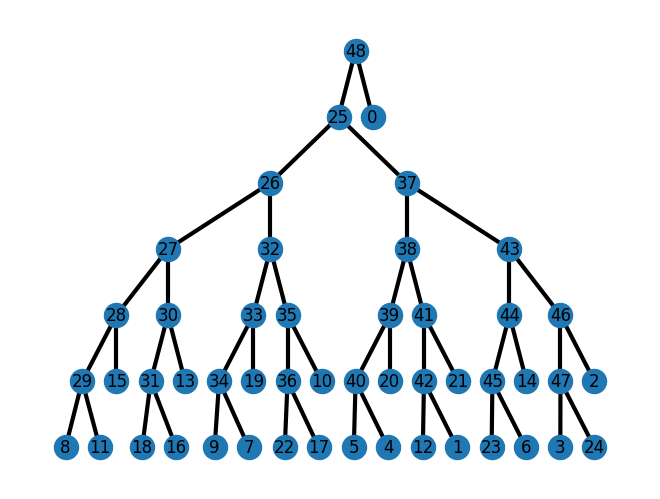

In [60]:
spanning_tree, spanning_root_ind = pyttn.generate_spanning_tree(correlation_matrix, max_internal_children=1, max_leaf_children=2)

tree, leaf_ordering = pyttn.convert_nx_to_tree(spanning_tree, root_ind=spanning_root_ind)

pyttn.utils.visualise_tree(tree)

##### The Heavy-Hex Graph

#### Hierarchical Clustering <a id="hierarchical-clustering"></a>

### Updating Tree Properties <a class="anchor" id="updating-tree-properties"></a>

### Traversing Trees <a class="anchor" id="traversing-trees"></a>

In order to allow for  functions are provided for traversing `ntree` objects.  These including